In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import sklearn

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas: 2.2.2
NumPy: 2.0.2
Matplotlib: 3.10.0
Scikit-learn: 1.9.0


In [2]:
!pip install scikit-learn==1.9.0

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("Mall_Customers.csv")

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [7]:
df.shape

(200, 5)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [13]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [14]:
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [16]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

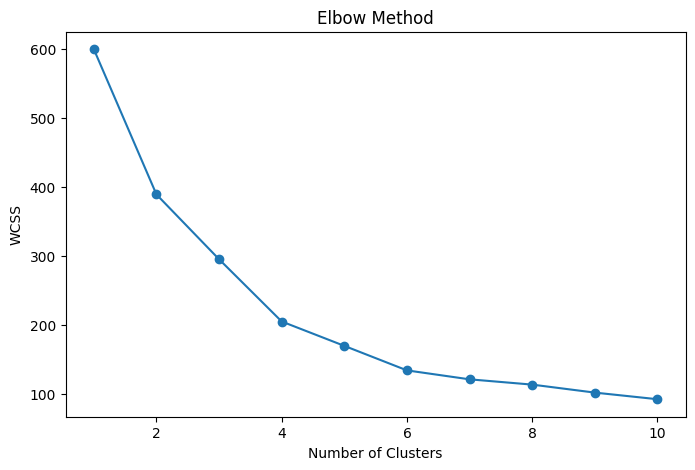

In [17]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [18]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

In [20]:
df["clusters"]=clusters

In [21]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [24]:
df["clusters"].value_counts()

,count
clusters,
0,58
3,45
1,40
4,31
2,26


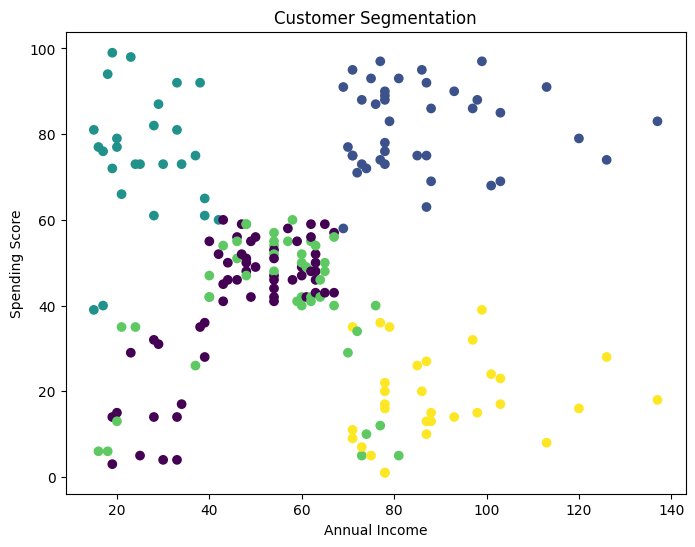

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["clusters"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.show()

In [32]:
df.groupby("clusters")[["Age","Annual Income (k$)","Spending Score (1-100)"]].mean()

,Age,Annual Income (k$),Spending Score (1-100)
clusters,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


In [33]:
kmeans.cluster_centers_

array([[ 1.17882975, -0.49388609, -0.32971553],
       [-0.42880597,  0.97484722,  1.21608539],
       [-0.93876351, -1.31473131,  0.95680216],
       [-0.86957306, -0.23851652, -0.36060916],
       [ 0.39737911,  1.11508909, -1.23126963]])

In [35]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers

array([[55.27586207, 47.62068966, 41.70689655],
       [32.875     , 86.1       , 81.525     ],
       [25.76923077, 26.11538462, 74.84615385],
       [26.73333333, 54.31111111, 40.91111111],
       [44.38709677, 89.77419355, 18.48387097]])

In [40]:
df.to_csv("Clustered_Customers.csv", index=False)

In [41]:
from google.colab import files

files.download("Clustered_Customers.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cluster Interpretation
Cluster 0
Average Age: 55.28 years
Annual Income: 47.62 k$
Spending Score: 41.71
Interpretation: Older customers with medium income and moderate spending behavior.
Cluster 1
Average Age: 32.88 years
Annual Income: 86.10 k$
Spending Score: 81.53
Interpretation: Young customers with high income and high spending score. These are premium and high-value customers.
Cluster 2
Average Age: 25.77 years
Annual Income: 26.12 k$
Spending Score: 74.85
Interpretation: Young customers with low income but high spending score. They are active shoppers despite lower income.
Cluster 3
Average Age: 26.73 years
Annual Income: 54.31 k$
Spending Score: 40.91
Interpretation: Young customers with average income and average spending score. These are regular customers.
Cluster 4
Average Age: 44.39 years
Annual Income: 89.77 k$
Spending Score: 18.48
Interpretation: Middle-aged customers with high income but low spending score. They have high purchasing power but spend less.